In [1]:
%load_ext autoreload
%autoreload 2

In [9]:
import numpy as np
from scipy import linalg as la
from koala import plotting as pl
from alter_morph.hamiltonians import (
    alt_hamiltonian,
    find_m_per_state,
    find_spin_per_state,
    spectral_function,
)
from alter_morph.lattice_utilities import alter_lattice_maker
from alter_morph.hamiltonians import _hopping_matrix
from alter_morph.mean_field import hartree_fock, single_hartree_fock_step

from tqdm import tqdm


# plotting
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)
aps_figwidth = 6.6
aps_halfwidth = 3.375

In [10]:
# make the lattice
system_length = 10
lattice_type = "square"
lattice = alter_lattice_maker(system_length, lattice_type)
# lattice = koala.graph_utils.cut_boundaries(lattice)
print(lattice)

Lattice(100 vertices, 200 edges)


In [ ]:
# make the parameters_to_sweep
def parameters(sweep_value):
    t1 = 1
    t2 = 0.5
    J = 0.5
    U = J
    filling = np.interp(sweep_value, [0, 1], [0.01, 0.99])
    initial_m = np.random.rand(lattice.n_vertices)-0.5  # initial magnetization
    initial_n = np.full(lattice.n_vertices, filling * 4)
    theta_offset = 0.0

    return {
        "t1": t1,
        "t2": t2,
        "J": J,
        "filling": filling,
        "initial_m": initial_m,
        "initial_n": initial_n,
        "theta_offset": theta_offset,
    }

In [13]:
resolution = 10


def perform_parameter_sweep(parameters, resolution=100):
    m_out = []
    n_out = []
    e_out = []
    s_out = []
    how_well_converged = []

    x_in = np.linspace(0, 1, resolution)
    for i in x_in:
        params = parameters(i)
        if i != 0:
            params["initial_m"] = m_out[-1]
            params["initial_n"] = n_out[-1]

        m_values, n_values = hartree_fock(
            lattice,
            params,
            1000,
            mixing_proportion=0.1,
            tol_mdiff=5e-3,
            verbose=True,
            leave=True,
            adjust_learning_rate=True,
        )
        # plt.plot(m_values)
        # plt.show()

        hamiltonian = alt_hamiltonian(
            lattice,
            params["t1"],
            params["t2"],
            params["J"],
            m_values[-1],
            n_values[-1],
            theta_offset=params["theta_offset"],
        )
        energies, states = la.eigh(hamiltonian)

        how_well_converged.append(len(m_values))

        current_m = m_values[-1] + np.random.normal(0, 0.01, lattice.n_vertices)
        current_n = n_values[-1] + np.random.normal(0, 0.01, lattice.n_vertices)

        m_out.append(current_m)
        n_out.append(current_n)
        e_out.append(energies)
        s_out.append(states)

    return m_out, n_out, e_out, s_out, how_well_converged


m_out, n_out, e_out, s_out, how_well_converged = perform_parameter_sweep(
    parameters, resolution
)

Avg:0.00, diff: 0.000024, zigzag: 0.2574, mix: 0.0951:   1%|          | 8/1000 [00:00<01:04, 15.38it/s]
Avg:-0.00, diff: 0.000102, zigzag: 0.4994, mix: 0.0500: 100%|██████████| 1000/1000 [00:52<00:00, 19.11it/s]
Avg:-0.01, diff: 0.000049, zigzag: 1.7022, mix: 0.3180:   1%|▏         | 14/1000 [00:00<00:52, 18.62it/s]
Avg:-0.01, diff: 0.000081, zigzag: 0.5186, mix: 0.3375:   2%|▏         | 22/1000 [00:01<00:53, 18.36it/s] 
Avg:-0.06, diff: 0.000098, zigzag: 0.4969, mix: 0.0500:  29%|██▊       | 286/1000 [00:16<00:40, 17.79it/s]
Avg:-0.06, diff: 0.000098, zigzag: 0.4964, mix: 0.0562:   9%|▉         | 89/1000 [00:05<00:52, 17.25it/s]
Avg:-0.01, diff: 0.000066, zigzag: 0.4511, mix: 0.2869:   3%|▎         | 28/1000 [00:01<00:53, 18.08it/s]
Avg:-0.01, diff: 0.000054, zigzag: 1.2336, mix: 0.4665:   2%|▏         | 17/1000 [00:00<00:53, 18.38it/s]
Avg:-0.04, diff: 0.000099, zigzag: 0.4990, mix: 0.0500:  72%|███████▏  | 719/1000 [01:02<00:24, 11.57it/s]
Avg:-0.00, diff: 0.000013, zigzag: 0.1107, 

NameError: name 'x_in' is not defined

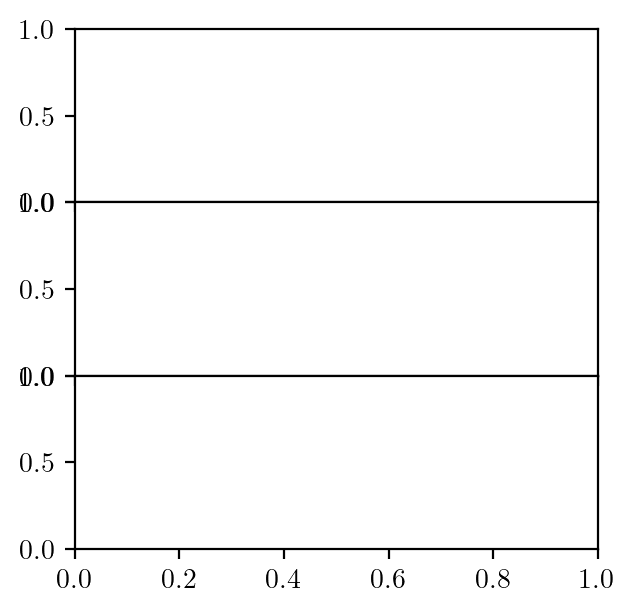

In [14]:
fig, ax = plt.subplots(
    3, 1, figsize=(aps_halfwidth, aps_halfwidth), sharex=True, dpi=200
)

fig.subplots_adjust(hspace=0)


# ax[0].plot(x_in,m_out,  alpha=0.4, linewidth=0.5)
ax[0].plot(x_in, np.mean(m_out, axis=1), color="black", linewidth=0.5)
ax[0].fill_between(
    x_in, np.quantile(m_out, 0, axis=1), np.quantile(m_out, 1, axis=1), alpha=0.8
)
ax[0].fill_between(
    x_in, np.quantile(m_out, 0.25, axis=1), np.quantile(m_out, 0.75, axis=1), alpha=1
)


ax[0].set_xlabel("Parameter")
ax[0].set_ylabel("$m$")

# ax[1].plot(x_in,n_out,  alpha=0.4, linewidth=0.5)
ax[1].plot(x_in, np.mean(n_out, axis=1), color="black", linewidth=0.5)
ax[1].fill_between(
    x_in, np.quantile(n_out, 0, axis=1), np.quantile(n_out, 1, axis=1), alpha=0.8
)
ax[1].fill_between(
    x_in, np.quantile(n_out, 0.25, axis=1), np.quantile(n_out, 0.75, axis=1), alpha=1
)
ax[1].set_ylabel("$\\rho$")

# ax[2].plot(x_in,e_out,  alpha=0.4, linewidth=0.5)
ax[2].plot(x_in, how_well_converged, color="black")


plt.show()

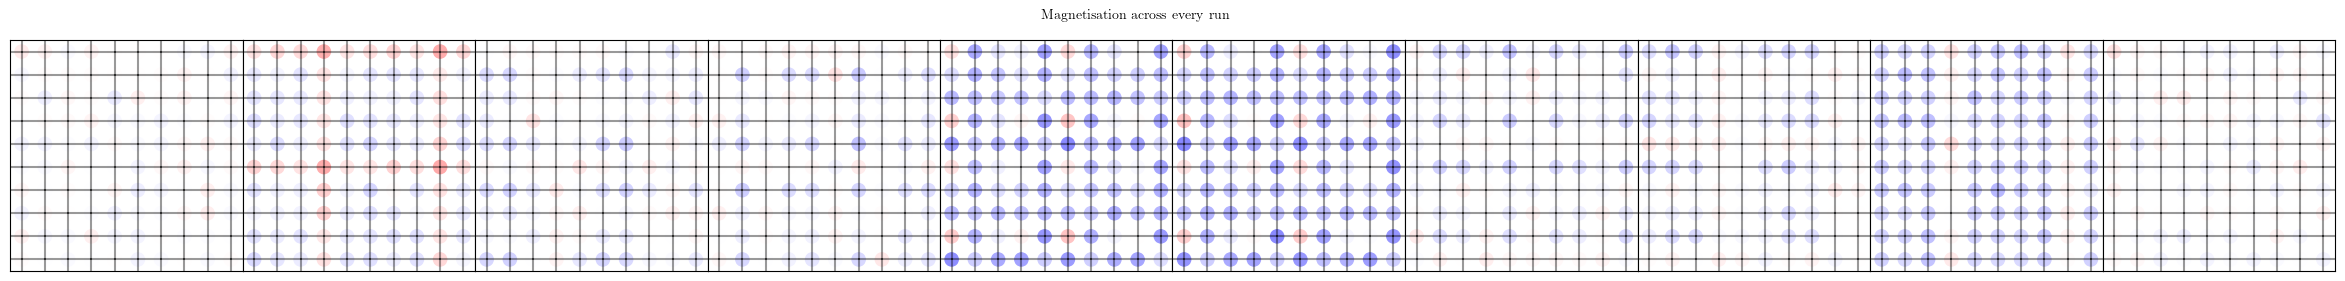

In [17]:
fig, ax = plt.subplots(resolution // 10, 10, figsize=(30, 3 * (resolution // 10)))
fig.subplots_adjust(hspace=0.0, wspace=0.0)
ax = ax.flatten()
# m_out = np.array(m_out)[::-1]

pos = lattice.vertices.positions
# copy four times for pb
n_sites = lattice.n_vertices
shifty = (
    [[0, 0]] * n_sites
    + [[0, 1]] * n_sites
    + [[1, 0]] * n_sites
    + [[0, -1]] * n_sites
    + [[-1, 0]] * n_sites
)
pos = np.concatenate([pos] * 5) + np.array(shifty)
site_mask = np.all(np.abs(pos - 0.5) < 0.6, axis=1)
pos = pos[site_mask]

for i in range(resolution):
    pl.plot_edges(lattice, ax=ax[i], alpha=0.4)
    im = ax[i].scatter(
        pos[:, 0],
        pos[:, 1],
        c=np.concatenate([m_out[i]] * 5)[site_mask],
        cmap="bwr",
        s=90,
        vmin=-0.3,
        vmax=0.3,
        zorder=-2,
    )
    # get rid of the axis labels
    ax[i].set_xticks([])
    ax[i].set_yticks([])

    # remove axes
    # ax[i].axis("off")

# overall title
fig.suptitle("Magnetisation across every run", fontsize=10)

plt.show()

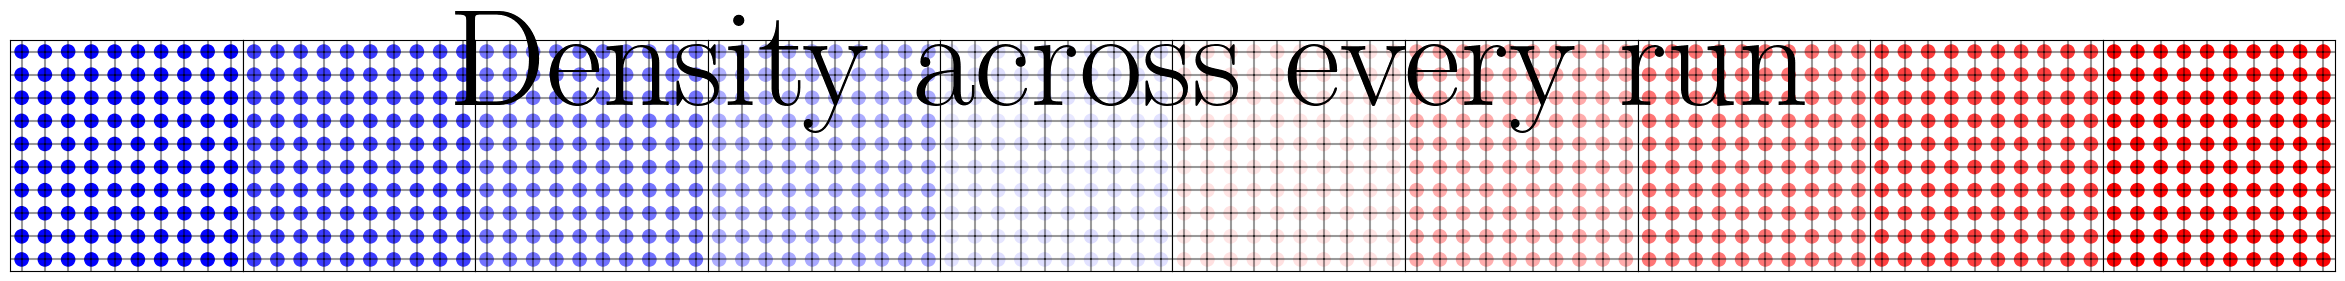

In [18]:
fig, ax = plt.subplots(resolution // 10, 10, figsize=(30, 3 * (resolution // 10)))
fig.subplots_adjust(hspace=0.0, wspace=0.0)
ax = ax.flatten()
# m_out = np.array(m_out)[::-1]

pos = lattice.vertices.positions
# copy four times for pb
n_sites = lattice.n_vertices
shifty = (
    [[0, 0]] * n_sites
    + [[0, 1]] * n_sites
    + [[1, 0]] * n_sites
    + [[0, -1]] * n_sites
    + [[-1, 0]] * n_sites
)
pos = np.concatenate([pos] * 5) + np.array(shifty)
site_mask = np.all(np.abs(pos - 0.5) < 0.6, axis=1)
pos = pos[site_mask]

for i in range(resolution):
    pl.plot_edges(lattice, ax=ax[i], alpha=0.4)
    im = ax[i].scatter(
        pos[:, 0],
        pos[:, 1],
        c=np.concatenate([n_out[i]] * 5)[site_mask],
        cmap="bwr",
        s=90,
        vmin=0,
        vmax=4,
        zorder=-2,
    )
    # get rid of the axis labels
    ax[i].set_xticks([])
    ax[i].set_yticks([])

    # remove axes
    # ax[i].axis("off")

# overall title
fig.suptitle("Density across every run", fontsize=100)

plt.show()